# Spectrogram Generation for Call Classification Model Training

### This notebook generates spectrograms in PyTorch (.pt) format from audio files to train the beluga call classification model.

We used to have dataset using 3s snippets, but then moved to 1s and labeled all the overlaps, as we move forward we should clean up how we handle the data, to have cleaner code.



In [1]:
from dotenv import load_dotenv
from pathlib import Path
import sys
import os

# Walk up until we find the project root (folder with the .env)
current_path = Path().resolve()
for parent in [current_path] + list(current_path.parents):
    if (parent / ".env").exists():
        load_dotenv(parent / ".env")
        project_root = os.getenv("PROJECT_ROOT")
        print(project_root)
        sys.path.append(project_root)     
        break


%load_ext autoreload
%autoreload 2

C:\Users\Admin\Desktop\Emmanuel\beluga-call-pipeline\


In [2]:

import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import librosa
from data_preprocessing.spectrogram.spectrogram_generator import HYDROPHONE_SENSITIVITY, SpectrogramGenerator
import pandas as pd
import torch

from tqdm import tqdm
import os


In [3]:
#Loading the labels for the overlaps
labels_df = pd.read_csv("../data/Verified_Dataset/labels/labels_merged.csv")


In [4]:
spect_generator = SpectrogramGenerator(
        n_fft=2048,
        hop_length=int(2048/2),
        n_mels=64,
        fmin=200,
        sample_rate=192000, 
    )

In [3]:

DATA_DIRECTORY = "../data/"

wavs_folder = DATA_DIRECTORY + "Verified_Dataset/clip_wavs/"
# wavs_folder_path_3s = DATA_DIRECTORY + "Full_Dataset/Snippets_3s_wav/"
# wavs_folder_path_1s = DATA_DIRECTORY + "Full_Dataset/New_Absences_1s/"

output_dir = DATA_DIRECTORY + "Verified_Dataset/spectrograms/"

In [5]:

DATA_DIRECTORY = "../data/"

wavs_folder = DATA_DIRECTORY + "Verified_Dataset/clip_wavs/"
# wavs_folder_path_3s = DATA_DIRECTORY + "Full_Dataset/Snippets_3s_wav/"
# wavs_folder_path_1s = DATA_DIRECTORY + "Full_Dataset/New_Absences_1s/"

output_dir = DATA_DIRECTORY + "Verified_Dataset/spectrograms/"
os.makedirs(output_dir, exist_ok=True)

# Get list of already processed files
processed_files = set(os.listdir(output_dir))

df_to_process = labels_df

for index, row in tqdm(df_to_process.iterrows(), total=df_to_process.shape[0]):
    processed_filename = row["clip_filename"].replace(".wav", ".pt")
    
    # Skip if file already exists
    if processed_filename in processed_files:
        continue

    file_path = wavs_folder + row["clip_filename"]

    audio, sr, original_sr = spect_generator.load_audio(file_path)

    power_spect = spect_generator.compute_mel_power_spect(audio)

    dB_spect = spect_generator.power_to_db(power_spect, hydrophone_sensitivity=row["HydrophoneSensitivity"])

    dB_spect_normalized = spect_generator.min_max_normalization(dB_spect)
    
    dB_spect_resized = spect_generator.resize_spect(dB_spect_normalized, img_shape=(244,244))

    try:
        torch.save(dB_spect_resized, output_dir + processed_filename)

    except Exception as e:
        print(e)

100%|██████████| 15518/15518 [02:31<00:00, 102.31it/s]


## Running the some tests using our trained model to make sure everything works correctly

In [6]:
from models.quant_mobilenet import load_mobilenet_v3_quant_from_file
from models.utils import get_best_device


model = load_mobilenet_v3_quant_from_file("../models/weights/mobile_net_8_layers_qat.pt", n_layers=8)

device = get_best_device()

model.to(device)

C:\Users\Admin\Desktop\Emmanuel\beluga-call-pipeline\models\quant_mobilenet.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location="

QuantizableMobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): QuantizableInvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU()
        )
        (1): QuantizableSqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
          (skip_mul): FloatFunctional(
            (activation_post_proces

CAC_20210717_15222385.wav 
Boat:  nan
nan
old_abs_from_3s_snippets


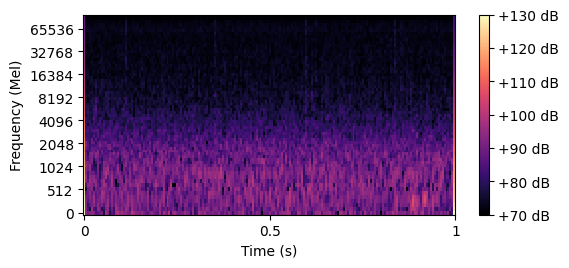

BSM_20170724_13475900.wav ECHO 
Boat:  1.0
nan
evaluation_v1


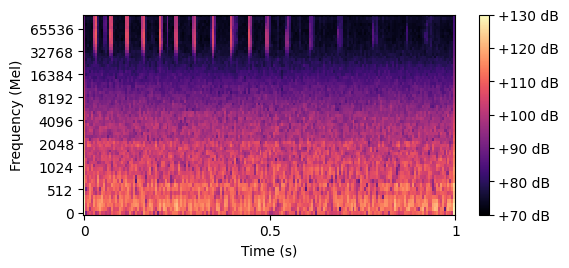

BSM_20170807_04540300.wav 
Boat:  nan
nan
old_abs_from_3s_snippets


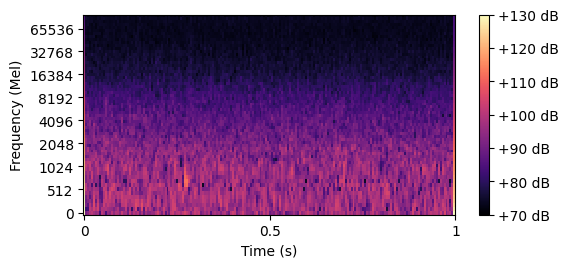

KAM_20200729_11324000.wav ECHO 
Boat:  1.0
nan
evaluation_v2


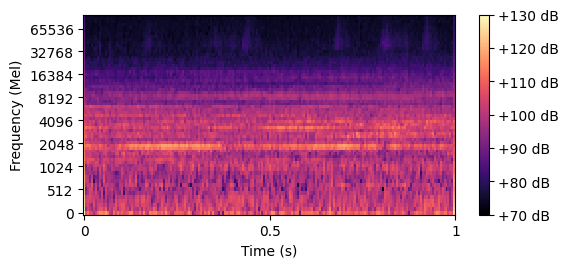

BSM_20170801_01110300.wav 
Boat:  nan
nan
old_abs_from_3s_snippets


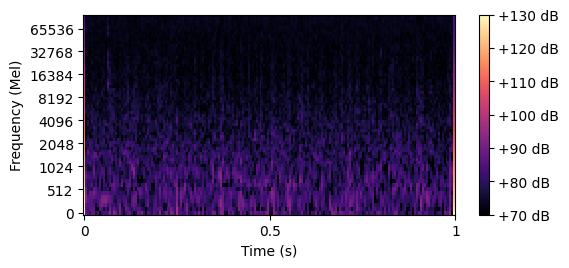

BSM_20220810_21380300.wav 
Boat:  nan
nan
old_abs_from_3s_snippets


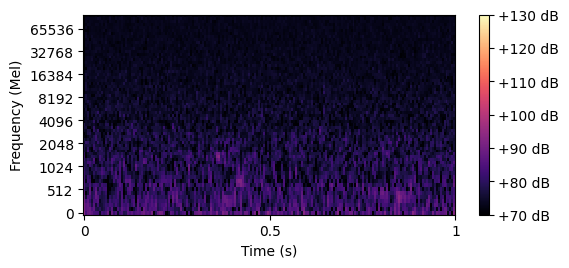

BSM_20170724_09482000.wav 
Boat:  1.0
nan
evaluation_v2


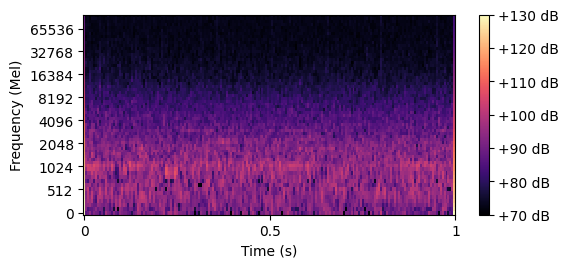

KAM_20200801_15021900.wav ECHO BBPC 
Boat:  0.0
nan
evaluation_v2


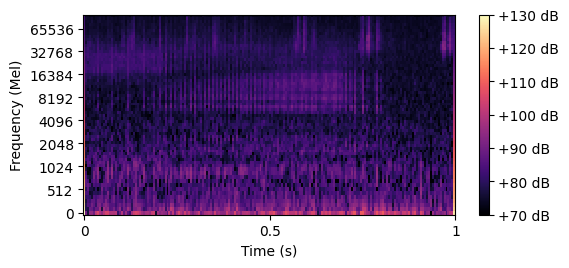

KAM_20200726_19565100.wav 
Boat:  1.0
nan
evaluation_v1


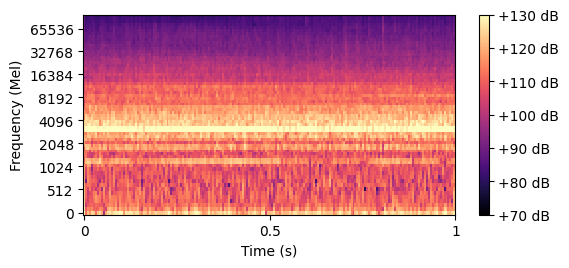

BSM_20170803_02330200.wav 
Boat:  nan
nan
old_abs_from_3s_snippets


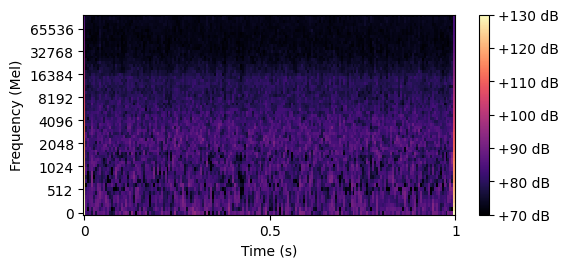

In [7]:

DATA_DIRECTORY = "../data/"

wavs_folder = DATA_DIRECTORY + "Verified_Dataset/clip_wavs/"

# sample = labels_df[labels_df["Notes"].notna()]
# sample = labels_df[labels_df["clip_filename"] == "CAC_20210714_08342600.wav"]
sample = labels_df.sample(10)




for index, row in sample.iterrows():    
    processed_filename = row["clip_filename"].replace(".wav", ".pt")
    
    title = ""
    title += f"{row['clip_filename']} "
    if row['ECHO'] == 1:
        title += "ECHO "
    if row['HFPC'] == 1:
        title += "HFPC "
    if row['BBPC'] == 1:
        title += "BBPC "
    if row['Whistle'] == 1:
        title += "Whistle "
    
    print(title)
    print("Boat: ", row["Boat"])
    print(row["Notes"])
    print(row["labeling_effort"])

    file_path = wavs_folder + row["clip_filename"]

    audio, sr, original_sr = spect_generator.load_audio(file_path)


    power_spect = spect_generator.compute_mel_power_spect(audio)

    
    dB_spect = spect_generator.power_to_db(power_spect, hydrophone_sensitivity=row["HydrophoneSensitivity"])
  

    spect_generator.plot_spect(dB_spect, figsize=(6,2.6), title="", tick_interval=0.5, colorbar_range=(70, 130), transparent_background=True)

    # dB_spect_normalized = spect_generator.min_max_normalization(dB_spect)
    
    # dB_spect_resized = spect_generator.resize_spect(dB_spect_normalized, img_shape=(244,244))

    

(192000,)
-0.004742104
-0.0036230558
dB_spect
(64, 188)
58.286278
127.47009


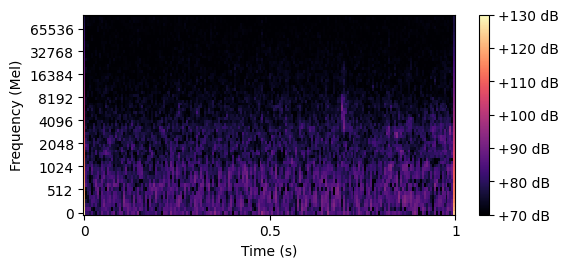

In [85]:
file_path = "../data/Verified_Dataset/clip_wavs/BSM_20210818_17440200.wav"
# file_path = "../data/Full_Dataset/Snippets_3s_wav/BSM_20210818_174400.wav"

audio, sr, original_sr = spect_generator.load_audio(file_path)

print(audio.shape)
print(min(audio))
print(max(audio))

power_spect = spect_generator.compute_mel_power_spect(audio)



dB_spect = spect_generator.power_to_db(power_spect, hydrophone_sensitivity=-172.7)
print("dB_spect")
print(dB_spect.shape)
print(dB_spect.min())
print(dB_spect.max())

spect_generator.plot_spect(dB_spect, figsize=(6,2.6), title="", tick_interval=0.5, colorbar_range=(70, 130), transparent_background=True)


C:\Users\Admin\AppData\Local\Temp\ipykernel_797112\3097811221.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  spect = torch.load(output_dir +"BSM_20170724_09480100.pt")


(244, 244)


c:\Users\Admin\Desktop\Emmanuel\beluga-call-pipeline\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


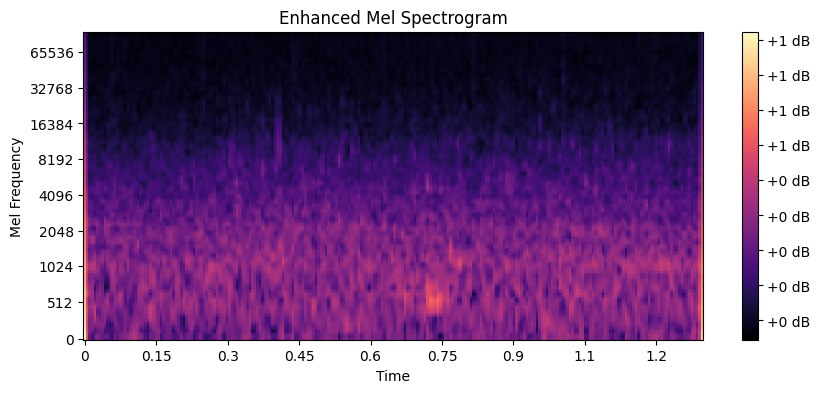

In [6]:
import torch
import matplotlib.pyplot as plt
import librosa
spect = torch.load(output_dir +"BSM_20170724_09480100.pt")
# plt.figure(figsize=(10, 4))
sr = 192000
# plt.imshow(spect, aspect='auto', origin='lower')
# res = classify(spect, model, device)
# print(res)
# plt.show(block=False)
print(spect.shape)
plt.figure(figsize=(10, 4))
librosa.display.specshow(spect, sr=sr, hop_length=1024, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Enhanced Mel Spectrogram')
plt.xlabel('Time')
plt.ylabel('Mel Frequency')
plt.show()